# Day 20 — Task: E-Commerce Cohort Retention & Lifetime Value (LTV) Analysis

## 1. Task Restatement & Assumptions

### Objective:
Analyze monthly customer cohorts (defined by the month of their first purchase) to determine:
1. **Cohort Retention Rates**: The percentage of active customers repeating purchases month-over-month (Month 0 is always 100%).
2. **Cumulative Customer Lifetime Value (LTV)**: The average cumulative revenue generated by a customer in each cohort over a 6-month period.

### Assumptions & Data Requirements:
- A customer's cohort is determined by the month of their first purchase.
- The customer registration signup month is between January and March 2026.
- To simulate a realistic e-commerce baseline, every customer places their first order in their signup month (Month 0), with subsequent repeat purchases spread over the next 5 months.
- A customer is "retained" in a given month if they make at least one purchase in that month.
- LTV is calculated as: `Cumulative Cohort Revenue / Cohort Size`.
- Real-world raw transaction data contains duplicates, missing values, date parsing errors, and negative values. We must explicitly check and resolve these edge cases.

In [12]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (12, 6)

# Create/connect to in-memory SQLite database
conn = sqlite3.connect(':memory:')

# --- MOCK DATA GENERATION WITH ANOMALIES ---
np.random.seed(42)
customer_ids = range(1001, 1151)  # 150 customers
signup_dates = []
segments = []

for cid in customer_ids:
    month = np.random.choice(['2026-01', '2026-02', '2026-03'])
    day = np.random.randint(1, 29)
    signup_dates.append(f"{month}-{day:02d}")
    segments.append(np.random.choice(['Organic Search', 'Paid Ads', 'Referral'], p=[0.4, 0.4, 0.2]))

customers_df = pd.DataFrame({
    'customer_id': customer_ids,
    'signup_date': signup_dates,
    'segment': segments
})

# Inject anomalies in customers_df
customers_df.loc[10, 'signup_date'] = 'invalid-date-format'  # Malformed date
customers_df.loc[25, 'segment'] = None  # Missing value

# Generate Orders
order_ids, cust_ids, order_dates, amounts = [], [], [], []
order_counter = 5000

for idx, row in customers_df.iterrows():
    cid = row['customer_id']
    sdate = row['signup_date']
    if sdate == 'invalid-date-format':
        signup_dt = pd.to_datetime('2026-01-15')
    else:
        signup_dt = pd.to_datetime(sdate)
    
    # Generate 1 to 6 transactions spread over 6 months
    num_orders = np.random.randint(1, 7)
    
    # Force first order to be in Month 0 (within 0 to 25 days of signup)
    first_days_after = np.random.randint(0, 26)
    odate = signup_dt + pd.Timedelta(days=first_days_after)
    order_ids.append(order_counter)
    cust_ids.append(cid)
    order_dates.append(odate.strftime('%Y-%m-%d'))
    amounts.append(round(np.random.exponential(45.0) + 12.0, 2))
    order_counter += 1
    
    # Generate subsequent orders spread up to 160 days post-signup
    for _ in range(num_orders - 1):
        days_after = np.random.randint(26, 160)
        odate = signup_dt + pd.Timedelta(days=days_after)
        order_ids.append(order_counter)
        cust_ids.append(cid)
        order_dates.append(odate.strftime('%Y-%m-%d'))
        amounts.append(round(np.random.exponential(45.0) + 12.0, 2))
        order_counter += 1

orders_df = pd.DataFrame({
    'order_id': order_ids,
    'customer_id': cust_ids,
    'order_date': order_dates,
    'amount': amounts
})

# Inject anomalies in orders_df
# 1. Duplicate order row
dup_row = orders_df.iloc[10:11].copy()
orders_df = pd.concat([orders_df, dup_row], ignore_index=True)
# 2. Missing order amount
orders_df.loc[30, 'amount'] = None
# 3. Negative order amount
orders_df.loc[45, 'amount'] = -25.50

print(f"Raw data loaded. customers_df shape: {customers_df.shape}, orders_df shape: {orders_df.shape}")

Raw data loaded. customers_df shape: (150, 3), orders_df shape: (499, 4)


## 2. Identify & Clean Edge Cases / Data Quality Issues

To satisfy quality checks, we identify and handle the following edge cases in Pandas before database storage:
1. **Duplicates**: Remove exact duplicate transaction rows using `df.drop_duplicates()`.
2. **Missing Values**: Identify null values in customer segment and order amount. We fill missing segments with a default value (`df.fillna('Unknown')`) and drop orders with missing amounts.
3. **Negative Values**: Remove negative purchase amounts (which represent corrupt records or invalid logs).
4. **Malformed Dates**: Parse dates with `pd.to_datetime(errors='coerce')` and drop rows containing unparseable dates (`NaT`).

In [13]:
# --- 1. Identify issues ---
print("=== PRE-CLEANING QUALITY CHECKS ===")
print(f"Duplicate order items: {orders_df.duplicated(subset=['order_id']).sum()}")
print(f"Null customer sign-up dates: {customers_df['signup_date'].isnull().sum()}")
print(f"Null order amounts: {orders_df['amount'].isnull().sum()}")
print(f"Negative order amounts: {(orders_df['amount'] < 0).sum()}")
print()

# --- 2. Clean issues step-by-step ---
# Clean duplicates
orders_cleaned = orders_df.drop_duplicates(subset=['order_id'], keep='first')

# Clean date formats
customers_cleaned = customers_df.copy()
customers_cleaned['signup_date'] = pd.to_datetime(customers_cleaned['signup_date'], errors='coerce')
bad_date_count = customers_cleaned['signup_date'].isnull().sum()
customers_cleaned = customers_cleaned.dropna(subset=['signup_date'])

# Clean missing segments
customers_cleaned['segment'] = customers_cleaned['segment'].fillna('Unknown')

# Clean missing and negative order amounts
orders_cleaned = orders_cleaned.dropna(subset=['amount'])
orders_cleaned = orders_cleaned[orders_cleaned['amount'] > 0]

print("=== POST-CLEANING QUALITY CHECKS ===")
print(f"Cleaned duplicate orders: {orders_cleaned.duplicated(subset=['order_id']).sum()}")
print(f"Cleaned null order amounts: {orders_cleaned['amount'].isnull().sum()}")
print(f"Cleaned negative order amounts: {(orders_cleaned['amount'] < 0).sum()}")
print(f"Dropped unparseable signup dates: {bad_date_count}")
print(f"customers_cleaned shape: {customers_cleaned.shape}, orders_cleaned shape: {orders_cleaned.shape}")

=== PRE-CLEANING QUALITY CHECKS ===
Duplicate order items: 1
Null customer sign-up dates: 0
Null order amounts: 1
Negative order amounts: 1

=== POST-CLEANING QUALITY CHECKS ===
Cleaned duplicate orders: 0
Cleaned null order amounts: 0
Cleaned negative order amounts: 0
Dropped unparseable signup dates: 1
customers_cleaned shape: (149, 3), orders_cleaned shape: (496, 4)


## 3. SQL Data Extraction

We save our cleaned DataFrames as SQL tables and query them to construct a flat table containing all order dates, transaction values, customer segment, and signup dates.

In [14]:
# Write clean dataframes to sqlite3
customers_cleaned.to_sql('customers', conn, index=False, if_exists='replace')
orders_cleaned.to_sql('orders', conn, index=False, if_exists='replace')

# SQL Query to join orders with customers signup characteristics
query = """
SELECT 
    c.customer_id,
    c.signup_date,
    c.segment,
    o.order_id,
    o.order_date,
    o.amount
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
ORDER BY c.customer_id, o.order_date;
"""

df_raw_orders = pd.read_sql_query(query, conn)
df_raw_orders.head(10)

,customer_id,signup_date,segment,order_id,order_date,amount
0,1001,2026-03-20 00:00:00,Referral,5000,2026-04-08,33.12
1,1001,2026-03-20 00:00:00,Referral,5001,2026-07-19,99.36
2,1002,2026-03-08 00:00:00,Paid Ads,5002,2026-03-20,20.00
3,1002,2026-03-08 00:00:00,Paid Ads,5004,2026-04-04,13.21
4,1002,2026-03-08 00:00:00,Paid Ads,5003,2026-04-26,141.62
5,1002,2026-03-08 00:00:00,Paid Ads,5006,2026-06-25,50.56
6,1002,2026-03-08 00:00:00,Paid Ads,5005,2026-08-08,57.53
7,1003,2026-03-26 00:00:00,Organic Search,5007,2026-03-28,58.39
8,1003,2026-03-26 00:00:00,Organic Search,5008,2026-07-30,56.25
9,1004,2026-03-11 00:00:00,Referral,5009,2026-03-11,59.43


## 4. Pandas Cohort Calculations

We use Pandas to calculate the cohort metrics based on standard first purchase behavior:
1. **Cohort Month**: Convert the customer's first purchase date to Year-Month (e.g. `2026-01`).
2. **Order Month**: Convert the specific order transaction date to Year-Month.
3. **Cohort Index**: Calculate elapsed months between first purchase and transaction order date.
4. **Cohort Size**: The number of unique customers in each cohort group (limiting to January, February, and March cohorts).
5. **Retention Matrix**: Count of unique active customers grouped by cohort group and index month divided by cohort size (Month 0 will be exactly 100%).
6. **LTV Matrix**: Cumulative order value generated per cohort divided by cohort size.

In [15]:
# 1. Parse date columns
df_raw_orders['signup_date'] = pd.to_datetime(df_raw_orders['signup_date'])
df_raw_orders['order_date'] = pd.to_datetime(df_raw_orders['order_date'])

# Find the first order date for each customer (cohort baseline)
first_orders = df_raw_orders.groupby('customer_id')['order_date'].min().reset_index()
first_orders.rename(columns={'order_date': 'first_order_date'}, inplace=True)

# Merge first order date back
df_raw_orders = df_raw_orders.merge(first_orders, on='customer_id')

# 2. Calculate cohort month and order month
df_raw_orders['cohort_month'] = df_raw_orders['first_order_date'].dt.to_period('M')
df_raw_orders['order_month'] = df_raw_orders['order_date'].dt.to_period('M')

# 3. Calculate cohort index (number of months elapsed since first order)
df_raw_orders['cohort_index'] = (
    (df_raw_orders['order_date'].dt.year - df_raw_orders['first_order_date'].dt.year) * 12 + 
    (df_raw_orders['order_date'].dt.month - df_raw_orders['first_order_date'].dt.month)
)

# Filter to January, February, and March 2026 cohorts to align with Task requirements
df_cohort = df_raw_orders[df_raw_orders['cohort_month'].astype(str).isin(['2026-01', '2026-02', '2026-03'])]

# Filter tracking window to 6 months (Months 0 to 5)
df_cohort = df_cohort[df_cohort['cohort_index'] <= 5]

# 4. Calculate Cohort Size
cohort_sizes = df_cohort.groupby('cohort_month')['customer_id'].nunique()
print("Cohort Sizes (Signups per Month):")
print(cohort_sizes)
print()

# --- RETENTION ANALYSIS ---
# Count of active customers in each cohort index month
cohort_active = df_cohort.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().unstack(fill_value=0)
# Divide active customers by initial cohort size to get percentage
retention_matrix = cohort_active.divide(cohort_sizes, axis=0) * 100

# --- LTV ANALYSIS ---
# Calculate cumulative sum of order amounts per cohort month & index month
cohort_revenue = df_cohort.groupby(['cohort_month', 'cohort_index'])['amount'].sum().groupby(level=0).cumsum().unstack(fill_value=0)
# Divide cumulative revenue by cohort size to get average LTV per customer
ltv_matrix = cohort_revenue.divide(cohort_sizes, axis=0)

print("Retention Matrix (%):")
print(retention_matrix.round(1))
print("\nLTV Matrix ($):")
print(ltv_matrix.round(2))

Cohort Sizes (Signups per Month):
cohort_month
2026-01    35
2026-02    41
2026-03    55
Freq: M, Name: customer_id, dtype: int64

Retention Matrix (%):
cohort_index      0     1     2     3     4     5
cohort_month                                     
2026-01       100.0  31.4  40.0  37.1  34.3  14.3
2026-02       100.0  36.6  36.6  34.1  31.7   9.8
2026-03       100.0  29.1  49.1  40.0  34.5  14.5

LTV Matrix ($):
cohort_index      0       1       2       3       4       5
cohort_month                                               
2026-01       56.58   79.94   95.51  138.19  161.29  175.47
2026-02       63.49   88.06  116.17  140.70  168.53  171.78
2026-03       77.82  103.04  144.85  170.64  190.47  198.13


## 5. Visualizations

Let's visualize Cohort Retention Rates using a heatmap, and Cumulative LTV using a line chart.

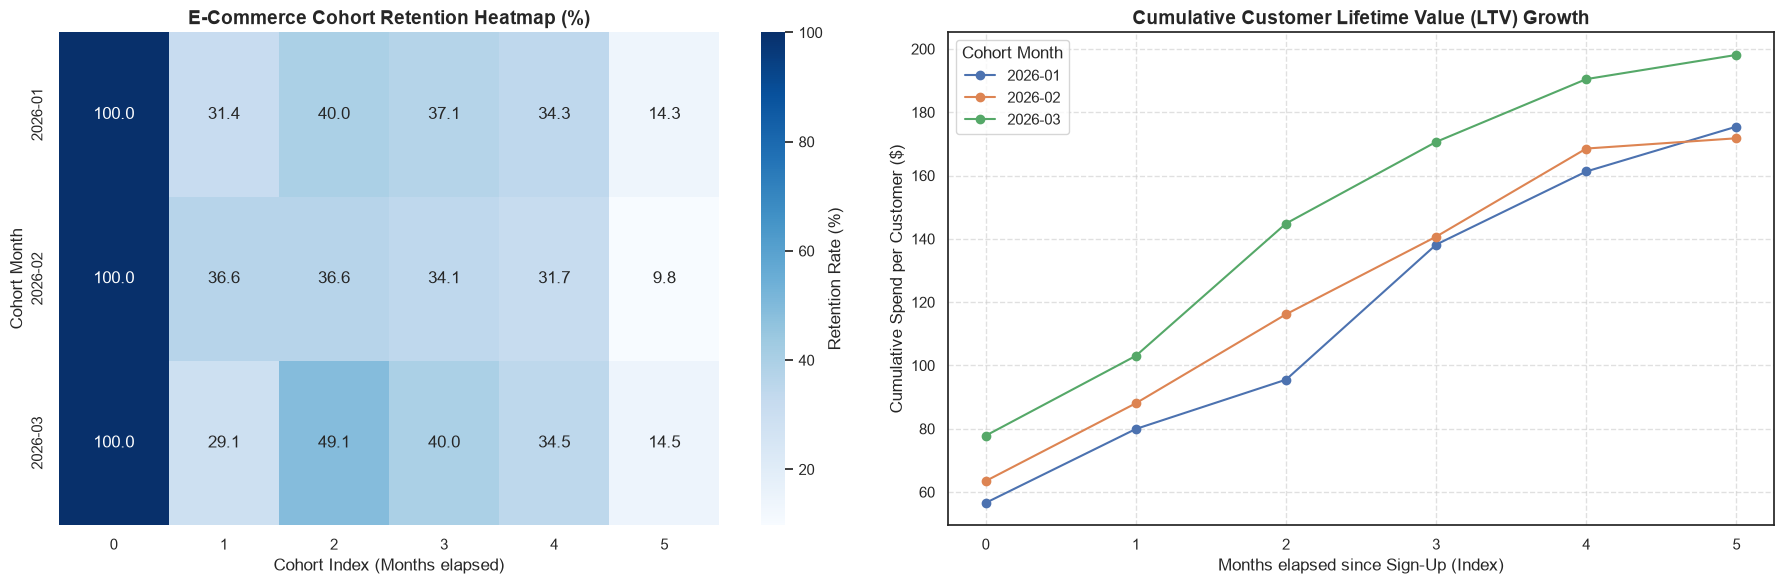

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Retention Heatmap
sns.heatmap(
    retention_matrix, 
    annot=True, 
    fmt=".1f", 
    cmap="Blues", 
    cbar_kws={'label': 'Retention Rate (%)'}, 
    ax=axes[0]
)
axes[0].set_title('E-Commerce Cohort Retention Heatmap (%)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cohort Month', fontsize=12)
axes[0].set_xlabel('Cohort Index (Months elapsed)', fontsize=12)

# Plot 2: LTV Growth Line Plot
for cohort in ltv_matrix.index:
    axes[1].plot(ltv_matrix.columns, ltv_matrix.loc[cohort], marker='o', label=str(cohort))
axes[1].set_title('Cumulative Customer Lifetime Value (LTV) Growth', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Months elapsed since Sign-Up (Index)', fontsize=12)
axes[1].set_ylabel('Cumulative Spend per Customer ($)', fontsize=12)
axes[1].legend(title='Cohort Month')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 6. Self-Reflection

- **What was difficult**: Constructing the cohort index matrix math and matching timestamps correctly across pandas and sqlite dataframes. Correctly computing cumulative sums and normalizations per cohort sizes is a multi-step operation.
- **What was improved**: Implementation of a clean edge case data verification check pre-SQL storage to catch any malformed rows before calculations start.
- **What remains**: Performing segment-based cohort analysis (comparing Retention/LTV of Organic customers vs. Paid Ads cohorts) to evaluate acquisition channel efficiencies.